In [2]:
import operator

def test(a,b,cmp,cname=None):
    if cname is None: cname=cmp.__name__
    assert cmp(a,b),f"{cname}:\n{a}\n{b}"

def test_eq(a,b): test(a,b,operator.eq,'==')

## Get data

In [3]:
# !pip install fastai

In [4]:
from pathlib import Path
from IPython.core.debugger import set_trace
# from fastai import datasets
import pickle, gzip, math, torch, matplotlib as mpl
import matplotlib.pyplot as plt
from torch import tensor

# MNIST_URL='http://deeplearning.net/data/mnist/mnist.pkl'

In [5]:
import os
import urllib.request

In [6]:
# The original deeplearning.net link is often dead.
# This is a reliable mirror for the exact pkl.gz file used in the lesson.
MNIST_URL = 'https://github.com/mnielsen/neural-networks-and-deep-learning/raw/master/data/mnist.pkl.gz'

# Set path to the local Colab content folder
path = Path('mnist.pkl.gz')

if not path.exists():
    print("Downloading MNIST pkl.gz...")
    urllib.request.urlretrieve(MNIST_URL, path)

print(f"File downloaded to: {path.absolute()}")

File downloaded to: /content/mnist.pkl.gz


In [7]:
# path = datasets.download_data(MNIST_URL, ext='.gz'); path

In [8]:
with gzip.open(path, 'rb') as f:
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding='latin-1')

- using pythons `map` to convert numpy arrays into pytorch `tensor`s
- everything you can do in numpy arrays you can also do in pytorch tensors but you can also do it on the GPU

In [9]:
x_train,y_train,x_valid,y_valid = map(tensor, (x_train,y_train,x_valid,y_valid))
n,c = x_train.shape
x_train, x_train.shape, y_train, y_train.shape, y_train.min(), y_train.max()

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 torch.Size([50000, 784]),
 tensor([5, 0, 4,  ..., 8, 4, 8]),
 torch.Size([50000]),
 tensor(0),
 tensor(9))

In [10]:
assert n==y_train.shape[0]==50000
test_eq(c,28*28)
test_eq(y_train.min(),0)
test_eq(y_train.max(),9)

In [11]:
mpl.rcParams['image.cmap'] = 'gray'

In [12]:
img = x_train[0]

In [13]:
img.view(28,28).type()

'torch.FloatTensor'

"`.view()` is really important" - this is how we reshape our `768` long vector into a `28,28` matrix that's suitable for plotting.

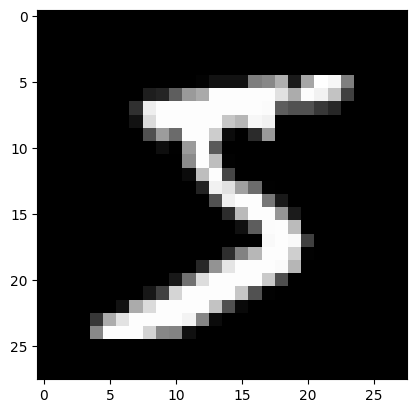

In [14]:
plt.imshow(img.view((28,28)));

## Initial python model
start by creating a simple linear model
- going to need to have something where **y = Ax + b**
  - our A will be a bunch of weights
  - needs to be a 784x10 matrix - 784 coming in and 10 going out
    - allows us to take in our independent variable (image) and map it to something with we compare to our dependent variable

In [15]:
weights = torch.randn(784,10)
bias = torch.zeros(10)

### Matrix Multiplication

we've got 3 things going on so we're going to need 3 loops
- n_rows (`ar`)
- columns (`bc`)
- multiply & add

In [16]:
def matmul(a,b):
    ar,ac = a.shape # n_rows * n_cols
    br,bc = b.shape
    assert ac==br
    c = torch.zeros(ar, bc)
    for i in range(ar):
        for j in range(bc):
            for k in range(ac): # or br
                c[i,j] += a[i,k] * b[k,j]
    return c

`c[i,j] += a[i,k] * b[k,j]` - this is the vast majority of what we're going to be doing in ML - so get very comfortable with this equation

notice:
- `i` also appears in a[0]
- `j` also appears in b[1]
- `k` in the loop appears twice - has to be the same number in each place because this is the bit where we're multiplying together elementwise

let's create a nice small version
- grab first 5 rows on validation set -> `m1`
- grad our weight matrix -> `m2`

In [17]:
m1 = x_valid[:5]
m2 = weights

In [18]:
m1.shape,m2.shape

(torch.Size([5, 784]), torch.Size([784, 10]))

notice the 2 elements of len `784` match as they should

In [19]:
%time t1=matmul(m1, m2)

CPU times: user 1.26 s, sys: 3.69 ms, total: 1.26 s
Wall time: 1.37 s


In [20]:
t1.shape

torch.Size([5, 10])

as you'd expect it's given us a 5x10 output

it took about a second for 5 rows - our MNIST dataset is 50,000 rows, so it's going to take ~50000 seconds to do a single matmul in python
- imagine doing MNIST where every layer for every pass took about 10 hours - not going to work - why we don't really write things in python

This is kinda slow - what if we could speed it up by 50,000 times? Let's try!

In [21]:
len(x_train)

50000

when we say python is too slow, we mean 1000's of times too slow  

"the way we speed things up, is we start in the inner-most loop, and we make each bit faster"
- The intuition is that in nested loops, the innermost part is where the actual "work" happens, and it's executed the most frequently.

The way to make python faster is to remove python - we remove python by passing our computation down to something that's written in something other than python, like pytorch (PyTorch behind the scenes in using a library called ATen ((C++/CUDA)) - the way we do this is by taking advantage of elementwise operations

### Elementwise ops
Operators (+,-,*,/,>,<,==) are usually element-wise.

Examples of element-wise operations:

In [22]:
a = tensor([10., 6, -4])
b = tensor([2., 8, 7])
a,b

(tensor([10.,  6., -4.]), tensor([2., 8., 7.]))

In [23]:
a + b

tensor([12., 14.,  3.])

In [24]:
(a < b).float().mean()

tensor(0.6667)

In [25]:
m = tensor([[1., 2, 3], [4,5,6], [7,8,9]]); m

tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])

In [26]:
(m*m).sum().sqrt()

tensor(16.8819)

### Elementwise matmul

In [27]:
def matmul(a,b):
    ar,ac = a.shape
    br,bc = b.shape
    assert ac==br
    c = torch.zeros(ar, bc)
    for i in range(ar):
        for j in range(bc):
            # Any trailing ",:" can be removed
            c[i,j] = (a[i,:] * b[:,j]).sum()
    return c

`(a[i,:] * b[:,j]).sum()` = multiply all of row `i` by all of col `j`, and that gives us back a rank 1 tensor which we add up

In [28]:
%timeit -n 10 _=matmul(m1, m2)

1.78 ms ± 178 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [29]:
890.1/5

178.02

we've removed 1 line of code and it's 178 times faster
- we've succssfully got rid of that inner loop
- now this is running in C
  - we didn't really write python here, we wrote kind of a pythonic thing that said "please call this C code for us"

In [30]:
#export
def near(a,b): return torch.allclose(a, b, rtol=1e-3, atol=1e-5)
def test_near(a,b): test(a,b,near)

In [31]:
test_near(t1,matmul(m1, m2))

Now to get rid of our next innermost loop we have to use; Broadcasting
## Broadcasting

- is about the most powerful tool we have in our toolbox for writing code in python that runs at C speed, or with PyTorch if you put it on the GPU it's going to run at CUDA speed
- it allows us to get rid of nearly all of our loops


The term broadcasting describes how arrays with different shapes are treated during arithmetic operations. The term broadcasting was first used by Numpy.

From the Numpy Documentation:

>The term broadcasting describes how numpy treats arrays with
different shapes during arithmetic operations. Subject to certain
constraints, the smaller array is “broadcast” across the larger
array so that they have compatible shapes. Broadcasting provides a
means of vectorizing array operations so that looping occurs in C
instead of Python. It does this without making needless copies of
data and usually leads to efficient algorithm implementations.

In addition to the efficiency of broadcasting, it allows developers to write less code, which typically leads to fewer errors.

### Broadcasting with a scalar

In [32]:
a

tensor([10.,  6., -4.])

In [33]:
a > 0

tensor([ True,  True, False])

In [34]:
a + 1

tensor([11.,  7., -3.])

In [35]:
m

tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])

In [36]:
m*2

tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.],
        [14., 16., 18.]])

that's the simplest kind of broadcasting

any time you do that, you're not operating at python speed but at C or CUDA speed

## Broadcasting a vector to a matrix
We can also broadcast a vector to a matrix:

In [37]:
c = tensor([10,20,30]); c

tensor([10, 20, 30])

In [38]:
m

tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])

In [39]:
m.shape, c.shape

(torch.Size([3, 3]), torch.Size([3]))

In [40]:
m + c

tensor([[11., 22., 33.],
        [14., 25., 36.],
        [17., 28., 39.]])

it broadcasts this row across each row of the matrix, and it's doing so at C speed
- there's no loop, but it appears like there's a loop

In [41]:
c + m

tensor([[11., 22., 33.],
        [14., 25., 36.],
        [17., 28., 39.]])

We don't really copy the rows, but it looks as if we did. In fact, the rows are given a stride of 0.

In [42]:
t = c.expand_as(m)

In [43]:
t

tensor([[10, 20, 30],
        [10, 20, 30],
        [10, 20, 30]])

In [44]:
m + t

tensor([[11., 22., 33.],
        [14., 25., 36.],
        [17., 28., 39.]])

this is great - means any time we need to do something between a vector & a matrix, we can do it at C speed with no loop

can look inside the actual memory used by PyTorch:

In [45]:
t.storage()

/tmp/ipykernel_295/1911556638.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  t.storage()


 10
 20
 30
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 3]

can see that it's only storing 1 copy of that data

In [46]:
t.stride(), t.shape

((0, 1), torch.Size([3, 3]))

- `t.shape` tells us that it knows it's meant to be a 3x3 matrix
- `t.stride()` tells us it knows that when it's going from col to col it should take `1` step throught the storage, but when it goes from row to row it should take `0` steps
  - that's why/how it repeats `10,20,30`


this is a really powerful thing that appears in nearly linalg library you come across; idea you can create tensors that behave like higher ranked things than they're actually stored as
- means this broadcasting functionality gives us C like speed with no additional memory overhead.



You can index with the special value [None] or use `unsqueeze()` to convert a 1-dimensional array into a 2-dimensional array (although one of those dimensions has value 1).

In [47]:
c

tensor([10, 20, 30])

In [48]:
c.unsqueeze(0)

tensor([[10, 20, 30]])

can create a rank 2 tensor of (3,1) from a rank 1 tensor by using the `unsqueeze` method
- adds an additional method of size 1 wherever we ask for it

In [49]:
c.unsqueeze(1)

tensor([[10],
        [20],
        [30]])

In [50]:
m

tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])

In [51]:
c.shape, c.unsqueeze(0).shape,c.unsqueeze(1).shape

(torch.Size([3]), torch.Size([1, 3]), torch.Size([3, 1]))

can index into an array with a special value `None` - means; squeeze a new axis in here

In [52]:
c.shape, c[None].shape,c[:,None].shape

(torch.Size([3]), torch.Size([1, 3]), torch.Size([3, 1]))

can also add additional axis this way

In [55]:
c.shape, c[None,None].shape,c[None,:,None].shape

(torch.Size([3]), torch.Size([1, 1, 3]), torch.Size([1, 3, 1]))

You can always skip trailling ':'s. And '...' means 'all preceding dimensions'

In [56]:
c[None].shape,c[...,None].shape

(torch.Size([1, 3]), torch.Size([3, 1]))

In [57]:
c[:,None].expand_as(m)

tensor([[10, 10, 10],
        [20, 20, 20],
        [30, 30, 30]])

In [58]:
m + c[:,None]

tensor([[11., 12., 13.],
        [24., 25., 26.],
        [37., 38., 39.]])

In [59]:
c[:,None]

tensor([[10],
        [20],
        [30]])

when we broadcast it is effectively taking & copying the unit axis so it's as long as the larger tensor on that axis
- however; it just pretends as if it's being copied

we can now use that to get rid of our loop - going through each of `range(bc)`

## Matmul with broadcasting

In [60]:
def matmul(a,b):
    ar,ac = a.shape
    br,bc = b.shape
    assert ac==br
    c = torch.zeros(ar, bc)
    for i in range(ar):
#       c[i,j] = (a[i,:]          * b[:,j]).sum() # previous
        c[i]   = (a[i  ].unsqueeze(-1) * b).sum(dim=0)
    return c

now, rather than setting `c[i,j]` we can set the entire row of `c[i]`
- this is the same as `c[i,:]`
  - anytime there's a trailing colon (`,:`) in numpy or pytorch you can delete it
  - similarly; can replace a `:,` at the start with `...`
    - can be super convenient for high ranked tensors - especially if you wanted to do something where the rank of the tensor could vary; you don't know how big it's going to be ahead of time

`c[i]   = (a[i  ].unsqueeze(-1) * b).sum(dim=0)`
- set the whole of row `c[i]` into row `a[i]` - now that we've got row `i` of `a`, that is a rank 1 tensor - use `.unsqueeze(-1)` to turn it into a rank 2 tensor
  - Note; `-1` always means the last dim. - could also have written it as `a[i,None]`
  - this is now of shape; `ar,1` (rank 2 tensor)
  - `b` is also a rank 2 tensor (that's the entirety of our matrix) -> so `a[i  ].unsqueeze(-1)` is going to get broadcast over `b` which is exactly what we want to get rid of that loop
  - because it broadcasts, that's going to return a rank 2 tensor which we then `.sum()` up over the rows `(dim=0)`



In [61]:
%timeit -n 10 _=matmul(m1, m2)

The slowest run took 4.25 times longer than the fastest. This could mean that an intermediate result is being cached.
221 µs ± 167 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [62]:
885000/277

3194.945848375451

at this point we're now 3200 times faster than python

In [63]:
test_near(t1, matmul(m1, m2))

## Broadcasting Rules

In [64]:
c[None,:]

tensor([[10, 20, 30]])

In [65]:
c[None,:].shape

torch.Size([1, 3])

In [66]:
c[:,None]

tensor([[10],
        [20],
        [30]])

In [67]:
c[:,None].shape

torch.Size([3, 1])

In [68]:
c[None,:] * c[:,None]

tensor([[100, 200, 300],
        [200, 400, 600],
        [300, 600, 900]])

In [69]:
c[None] > c[:,None]

tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])

Note: numpy / pytorch / TF all follow the same rules

When operating on two arrays/tensors, Numpy/PyTorch compares their shapes element-wise. It starts with the trailing dimensions, and works its way forward. Two dimensions are compatible when

- they are equal, or
- one of them is 1, in which case that dimension is broadcasted to make it the same size

Arrays do not need to have the same number of dimensions. For example, if you have a 256*256*3 array of RGB values, and you want to scale each color in the image by a different value, you can multiply the image by a one-dimensional array with 3 values. Lining up the sizes of the trailing axes of these arrays according to the broadcast rules, shows that they are compatible:

    Image  (3d array): 256 x 256 x 3
    Scale  (1d array):             3
    Result (3d array): 256 x 256 x 3

this comes up a lot as images are often normalized by channel
- the per channel mean; rank 1 tensor of size 3
- compatible because a 1 is inserted anywhere there is a missing dim (it's leading dims are set to 1)
- Note" PyTorch is CxHxW so it's slightly different

Our goal is to make our python code 50,000 times faster, so far it's 3200 times faster - the reason this is really important is because if we're going to be doing our own stuff such as building things that haven't been build before, need to know how to write code quickly & concisely but operates fast enough that it's useful
- broadcasting is perhaps the most important trick to know about

## Einstein summation
Einstein summation (`einsum`) is a compact representation for combining products and sums in a general way. From the numpy docs:

"The subscripts string is a comma-separated list of subscript labels, where each label refers to a dimension of the corresponding operand. Whenever a label is repeated it is summed, so `np.einsum('i,i', a, b)` is equivalent to `np.inner(a,b)`. If a label appears only once, it is not summed, so `np.einsum('i', a)` produces a view of a with no changes."

- 'another "magic" trick, not as cool as broadcasting but still very cool'

In [72]:
# c[i,j] += a[i,k] * b[k,j]             # innermost part of our original matmul for loop
# c[i,j] = (a[i,:] * b[:,j]).sum()      # version where we removed the innermost loop and replaced it with an element-wise product
def matmul(a,b): return torch.einsum('ik,kj->ij', a, b)

going to create something of size ij by doing dot products over these shared k's

notice: the repeated `k` got replaced with a colon

In [78]:
%timeit -n 10 _=matmul(m1, m2)

The slowest run took 9.03 times longer than the fastest. This could mean that an intermediate result is being cached.
66.9 µs ± 69.5 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [79]:
885000/55

16090.90909090909

In [80]:
test_near(t1, matmul(m1, m2))

### pytorch op
We can use pytorch's function or operator directly for matrix multiplication.

In [83]:
%timeit -n 10 t2 = m1.matmul(m2)

The slowest run took 7.45 times longer than the fastest. This could mean that an intermediate result is being cached.
19.4 µs ± 22.3 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [84]:
# time comparison vs pure python:
885000/18

49166.666666666664

as we can see, `matmul` takes 18 microseconds which is 50,000 times faster that python!

**why is it so fast?**
- if you think about what you're doing when you do a matrix multiply of something that's eg; 50000x768x768x10
- these are things that aren't going to fit inside the cache in your cpu, so if you do the standard solution of going down all the rows by all the cols, by the time you've got to the end and you go back to exactly the same col again it forgot the contents and has to go back to RAM and pull it in again
  - so if you're smart, you break your matrix up into smaller matrices and do a little bit at a time - that way everything's kind of in cache and it goes super fast
  - normally to do that you have to write kind of assembly language code (particularly if you want to get it all running in your vector processor, and that's how you get these 18 microseconds)
  - currently to get a fast matmul, things like pytorch don't write it themselves, they basically push that off to something called a **BLAS** (**Basic Linear Algebra Subprograms** Library), where companies like intel & AMD & Nvidia write these things for you
    - eg; **cuBLAS** (Nvidias version of BLAS)
    - **MKL** (Intels version of BLAS)
  - this is not ideal (awful in Jeremy's words), because the program is  limited to this subset of things that your BLAS can handle, and to use it you don't really get to write it in Python, you kind of have to write the one thing (`matmul`) that gets turned into that pre-existing BLAS call


so wherever possible, today, we want to use operations that are predefined in our library, particularly for things that operate over lots of rows & cols - the things where we're dealing with this memory cacheing stuff is going to be complicated

In [85]:
t2 = m1@m2

In [86]:
test_near(t1, t2)

In [87]:
m1.shape,m2.shape

(torch.Size([5, 784]), torch.Size([784, 10]))

matrix multiplicate is so popular it has its own operator;  
- `@` and `.matmul()` are calling the exact same code so they're the exact same speed
- `@` is not actually just matrix multiplication, it covers a much broader array of tensor reductions across different levels of axes, so it's wortch checking out what `matmul` can do because often it'll be able to handle things like batchwise or matrix vs vectors - don't think of it as something that can only do rank2xrank2 because it's a bit more flexible

We now have matrix multiplication, so now we're allowed to use it!
- going to use it to create a forward pass, which means we first need ReLU & Matrix Initialization
- remember: our model contain params which start out randomly initialized, then we use the grads to gradially update them with SGD